Importing Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import pickle

with open("../models/best_model_rf.pkl", "rb") as f:
    best_rf = pickle.load(f)

X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

Intializing Shap

In [2]:
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test)

features that have impact on churning

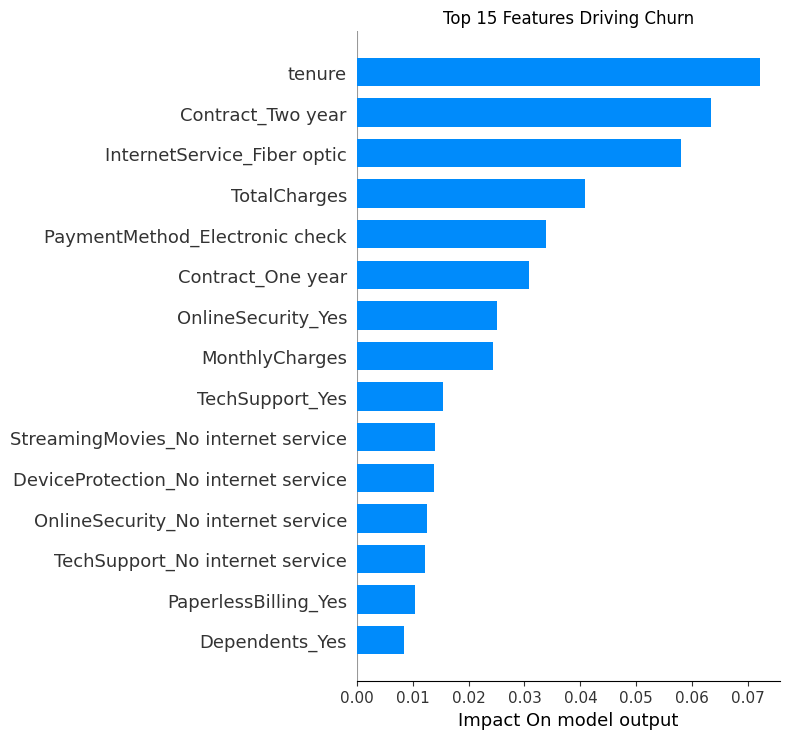

In [ ]:
from matplotlib.axis import XAxis

shap.summary_plot(
    shap_values[:, :, 1],
    X_test,
    plot_type='bar',
    max_display=15,
    show=False       
)
plt.xlabel("Impact On model output")
plt.title("Top 15 Features Driving Churn")
plt.tight_layout()
plt.savefig("../reports/figures/shap_feature_importance.png", dpi=150)
plt.show()

Shap Dot plot

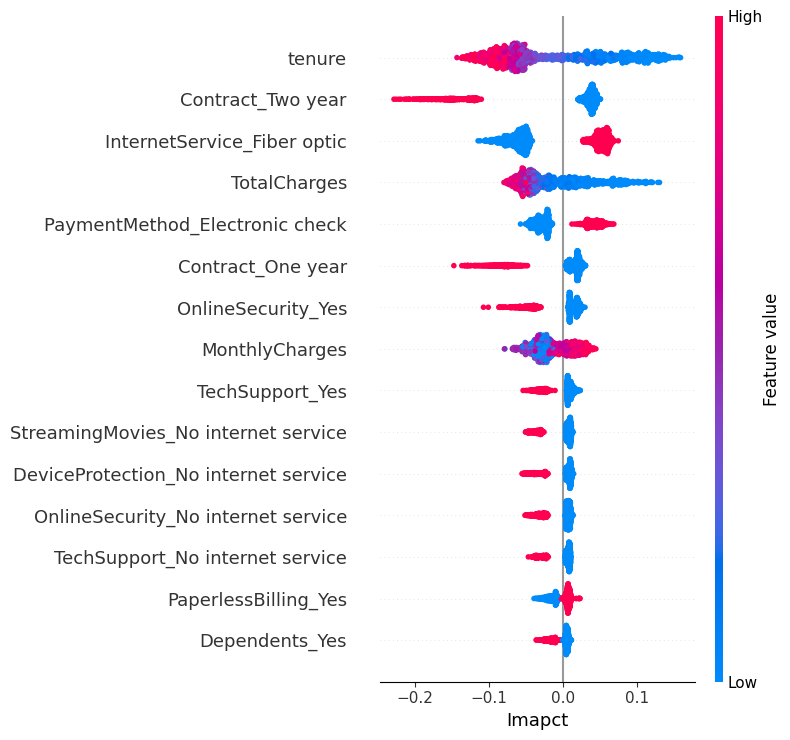

In [17]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_test,
    max_display=15,
    show = False
)
plt.xlabel("Imapct")
plt.tight_layout()
plt.savefig("../reports/figures/shap_summary.png", dpi=150)
plt.show()

An example of a single Customer

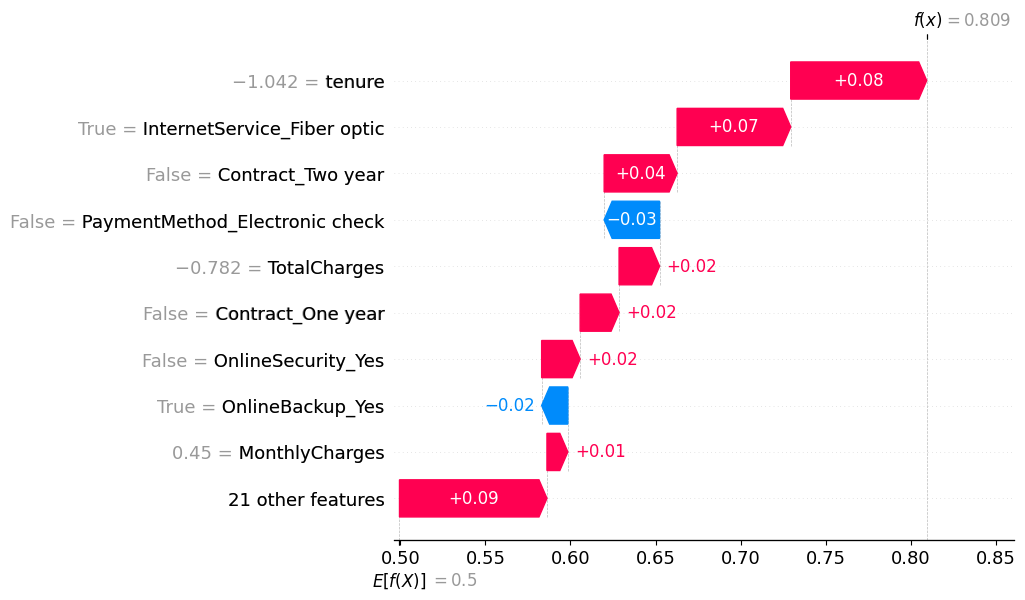

<Figure size 640x480 with 0 Axes>

In [ ]:
churn_indices = np.where(best_rf.predict(X_test) == 1)[0]
customer_idx = churn_indices[0]

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[customer_idx, :, 1],
        base_values=explainer.expected_value[1],
        data=X_test.iloc[customer_idx],
        feature_names=X_test.columns.tolist()
    )
)
plt.tight_layout()
plt.savefig("../reports/figures/shap_single_customer.png", dpi=150)
plt.show()